# BA305 Fraud Detection Project

**By: Joshua Leeds, Thomas Yousef, Kyle Yu**

**Research Questions:**
1. **Q1:** What are the most important features that influence fraud vs. non-fraud?
2. **Q2:** Which model best detects fraud? (Logistic Regression + PCA vs. Random Forest)
3. **Q3:** What is the financial cost of fraud, and how much does threshold tuning save?

**Structure:** EDA → Shared Data Preparation → Q1 (RF, LR) → Q2 (LR, RF) → Q3

### Note on AI usage

AI was used for code generation, but all outputs were reviewed and validated by the team. However, code was written by AI specifically Claude and GitHub Copilot. All code ideas were generated by the team, and AI was used to generate the code and assist with the implementation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, f1_score, recall_score, precision_score
)
import warnings
warnings.filterwarnings('ignore')

INVESTIGATOR_COST = 25  # $ per false alarm
PRECISION_FLOOR   = 0.10

---
## 1. Exploratory Data Analysis

In [2]:
df = pd.read_csv('Financial_Fraud_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"Overall fraud rate: {df['isFraud'].mean()*100:.4f}%")
df.head()

Dataset shape: (6362620, 11)
Overall fraud rate: 0.1291%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print(df.info())
display(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00



Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [4]:
feature_summary = pd.DataFrame({
    'Feature': ['step','type','amount','nameOrig','oldbalanceOrg',
                'newbalanceOrig','nameDest','oldbalanceDest','newbalanceDest',
                'isFraud','isFlaggedFraud'],
    'Type': ['Numerical','Categorical','Numerical','Categorical','Numerical',
             'Numerical','Categorical','Numerical','Numerical',
             'Binary (Target)','Binary'],
    'Description': [
        'Time step (proxy for time, 1-743)',
        'Transaction type: PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN',
        'Transaction amount in local currency',
        'Sender account ID', 'Sender balance before transaction',
        'Sender balance after transaction', 'Receiver account ID',
        'Receiver balance before transaction', 'Receiver balance after transaction',
        '1 = Fraud, 0 = Legitimate',
        '1 = System-flagged fraud (only 16 flagged vs 8,213 actual — not used)'
    ]
})
display(feature_summary)

,Feature,Type,Description
0,step,Numerical,"Time step (proxy for time, 1-743)"
1,type,Categorical,"Transaction type: PAYMENT, TRANSFER, CASH_OUT,..."
2,amount,Numerical,Transaction amount in local currency
3,nameOrig,Categorical,Sender account ID
4,oldbalanceOrg,Numerical,Sender balance before transaction
5,newbalanceOrig,Numerical,Sender balance after transaction
6,nameDest,Categorical,Receiver account ID
7,oldbalanceDest,Numerical,Receiver balance before transaction
8,newbalanceDest,Numerical,Receiver balance after transaction
9,isFraud,Binary (Target),"1 = Fraud, 0 = Legitimate"


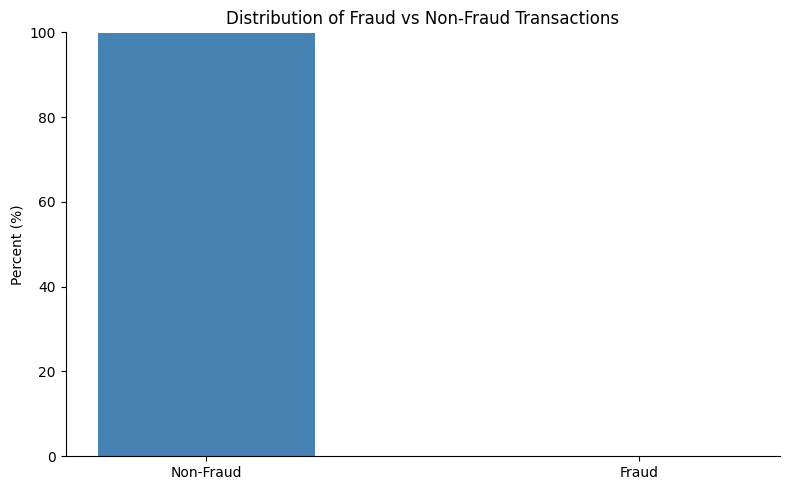

Fraud: 0.1291% | Non-Fraud: 99.8709%


In [5]:
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 5))
plt.bar(['Non-Fraud', 'Fraud'], [fraud_pct[0], fraud_pct[1]], color='steelblue', width=0.5)
plt.title('Distribution of Fraud vs Non-Fraud Transactions')
plt.ylabel('Percent (%)')
plt.ylim(0, 100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Fraud: {fraud_pct[1]:.4f}% | Non-Fraud: {fraud_pct[0]:.4f}%")

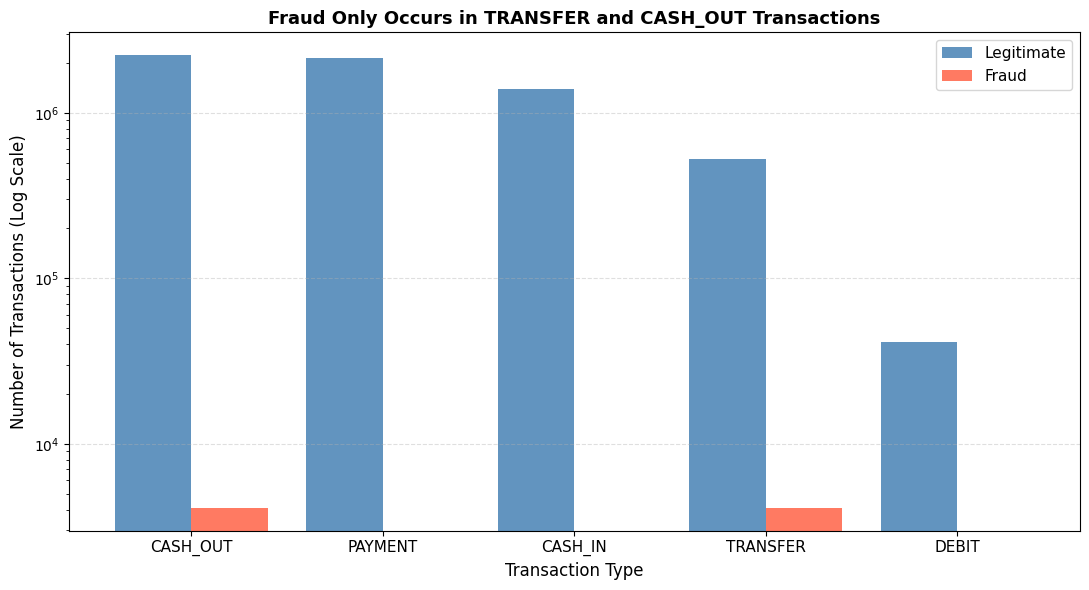

In [6]:
type_fraud = df.groupby('type')['isFraud'].agg(['sum','count']).reset_index()
type_fraud.columns = ['type','Fraud','Total']
type_fraud['Legitimate'] = type_fraud['Total'] - type_fraud['Fraud']
type_fraud = type_fraud.sort_values('Total', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(type_fraud))
w = 0.4
ax.bar([i-w/2 for i in x], type_fraud['Legitimate'], width=w, label='Legitimate', color='steelblue', alpha=0.85)
ax.bar([i+w/2 for i in x], type_fraud['Fraud'],      width=w, label='Fraud',      color='tomato',    alpha=0.85)
ax.set_yscale('log')
ax.set_xticks(list(x))
ax.set_xticklabels(type_fraud['type'], fontsize=11)
ax.set_xlabel('Transaction Type', fontsize=12)
ax.set_ylabel('Number of Transactions (Log Scale)', fontsize=12)
ax.set_title('Fraud Only Occurs in TRANSFER and CASH_OUT Transactions', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [7]:
df_filt = df[df['type'].isin(['TRANSFER','CASH_OUT'])].copy()
print(f"Original: {df.shape[0]:,} rows | Fraud: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.4f}%)")
print(f"Filtered: {df_filt.shape[0]:,} rows | Fraud: {df_filt['isFraud'].sum():,} ({df_filt['isFraud'].mean()*100:.4f}%)")
print(f"Rows removed: {df.shape[0]-df_filt.shape[0]:,} (0 fraud cases lost)")
print(f"\nBaseline accuracy (predict all = Not Fraud): {(df_filt['isFraud']==0).mean()*100:.4f}%")

Original: 6,362,620 rows | Fraud: 8,213 (0.1291%)
Filtered: 2,770,409 rows | Fraud: 8,213 (0.2965%)
Rows removed: 3,592,211 (0 fraud cases lost)

Baseline accuracy (predict all = Not Fraud): 99.7035%


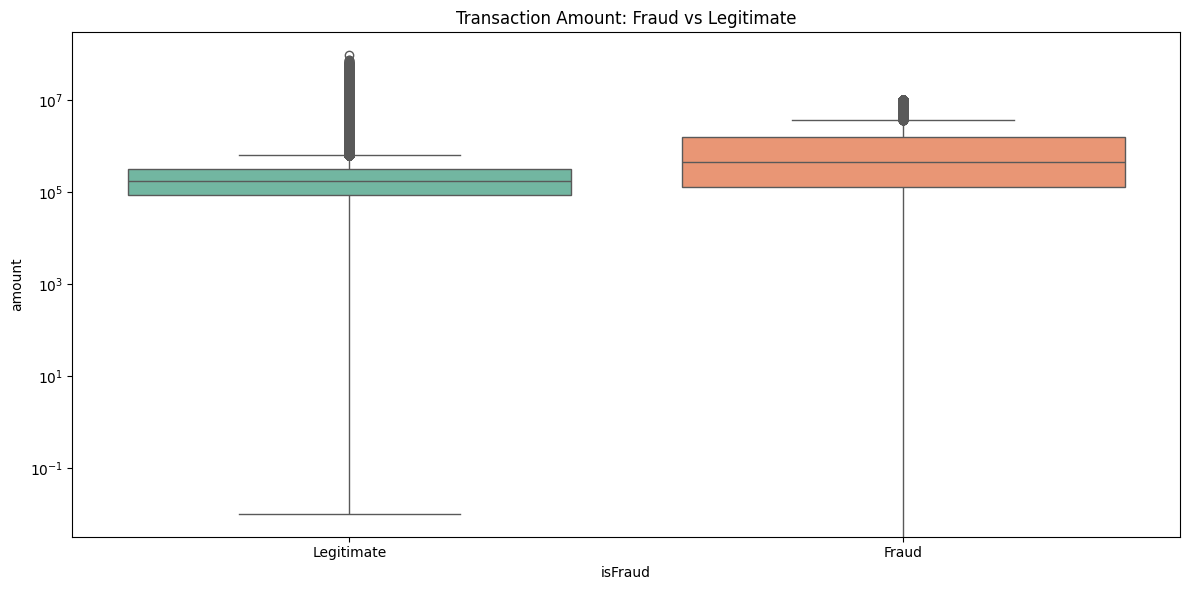

Average transaction amount:
isFraud
Legitimate    3.141155e+05
Fraud         1.467967e+06
Name: amount, dtype: float64


In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='isFraud', y='amount', data=df_filt, palette='Set2')
plt.title('Transaction Amount: Fraud vs Legitimate')
plt.yscale('log')
plt.xticks([0,1], ['Legitimate','Fraud'])
plt.tight_layout()
plt.show()
print("Average transaction amount:")
print(df_filt.groupby('isFraud')['amount'].mean().rename({0:'Legitimate',1:'Fraud'}))

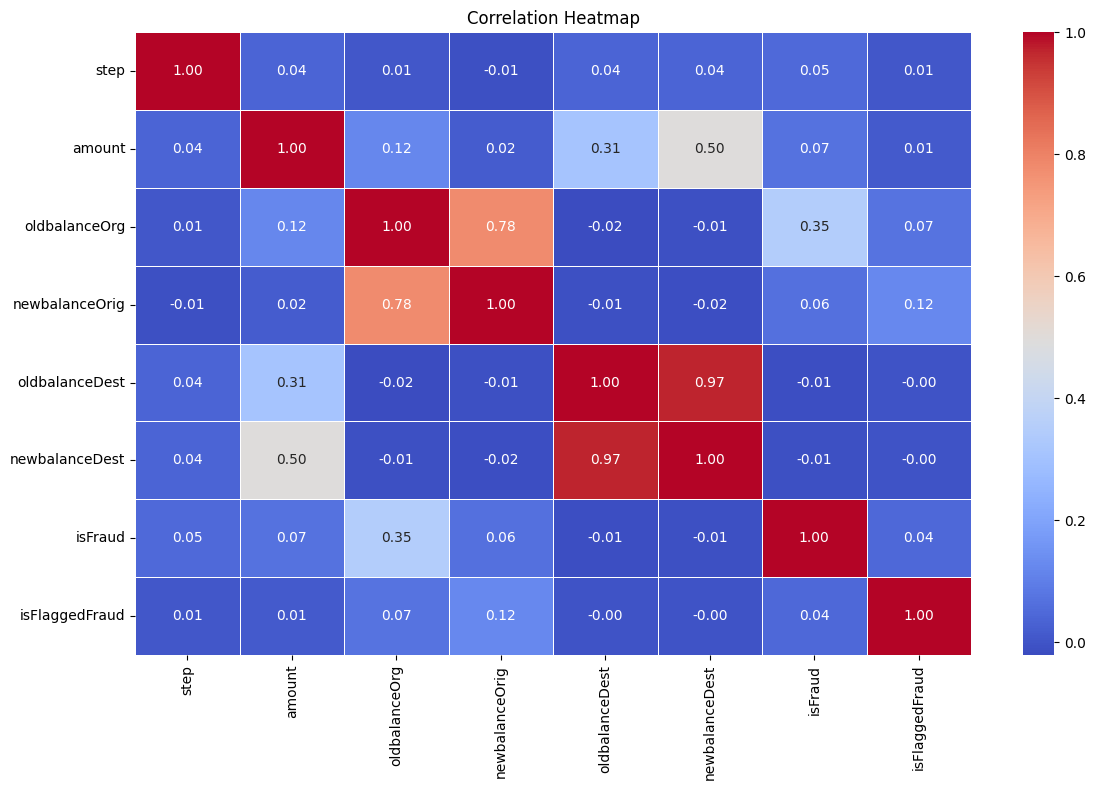

In [9]:
corr = df_filt.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## Data Preparation

Feature engineering and train/test split run **once here** and are reused by all models in Q1, Q2, and Q3.


In [10]:
df = pd.read_csv('Financial_Fraud_dataset.csv')
df = df[df['type'].isin(['TRANSFER','CASH_OUT'])].copy()

df['type_encoded']     = (df['type'] == 'TRANSFER').astype(int)
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['origDrained']      = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)
df['destUnchanged']    = (df['newbalanceDest'] == df['oldbalanceDest']).astype(int)
df['log_amount']       = np.log1p(df['amount'])

FEATURES = [
    'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origDrained', 'destUnchanged',
    'type_encoded',
]

split_step = int(df['step'].quantile(0.80))
train_df   = df[df['step'] <= split_step]
test_df    = df[df['step'] >  split_step]

X_train      = train_df[FEATURES].values
y_train      = train_df['isFraud'].values
X_test       = test_df[FEATURES].values
y_test       = test_df['isFraud'].values
amounts_test = test_df['amount'].values

print(f"Split at step {split_step}")
print(f"Train: {len(X_train):,} samples | Fraud: {y_train.sum():,} ({y_train.mean()*100:.4f}%)")
print(f"Test:  {len(X_test):,} samples  | Fraud: {y_test.sum():,} ({y_test.mean()*100:.4f}%)")
print(f"\nTotal fraud value in test set: ${amounts_test[y_test==1].sum():,.2f}")
print(f"Average fraud transaction:     ${amounts_test[y_test==1].mean():,.2f}")

Split at step 354
Train: 2,217,905 samples | Fraud: 3,955 (0.1783%)
Test:  552,504 samples  | Fraud: 4,258 (0.7707%)

Total fraud value in test set: $6,702,594,765.36
Average fraud transaction:     $1,574,118.08


---
## Research Question 1: What are the most important features that influence fraud vs. non-fraud?

We use two methods:
1. **Random Forest Gini Importance** — how much each feature reduces impurity
2. **Logistic Regression Coefficients** — how strongly each feature pushes predicted probability toward fraud

### Method 1 — Random Forest Gini Importance

In [11]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=None, min_samples_leaf=1,
    class_weight='balanced_subsample', n_jobs=-1, random_state=42
)
print("Training Random Forest...")
rf.fit(X_train, y_train)
rf_proba_q1 = rf.predict_proba(X_test)[:, 1]
print(f"Training complete. Test PR-AUC: {average_precision_score(y_test, rf_proba_q1):.4f}")

Training Random Forest...
Training complete. Test PR-AUC: 1.0000


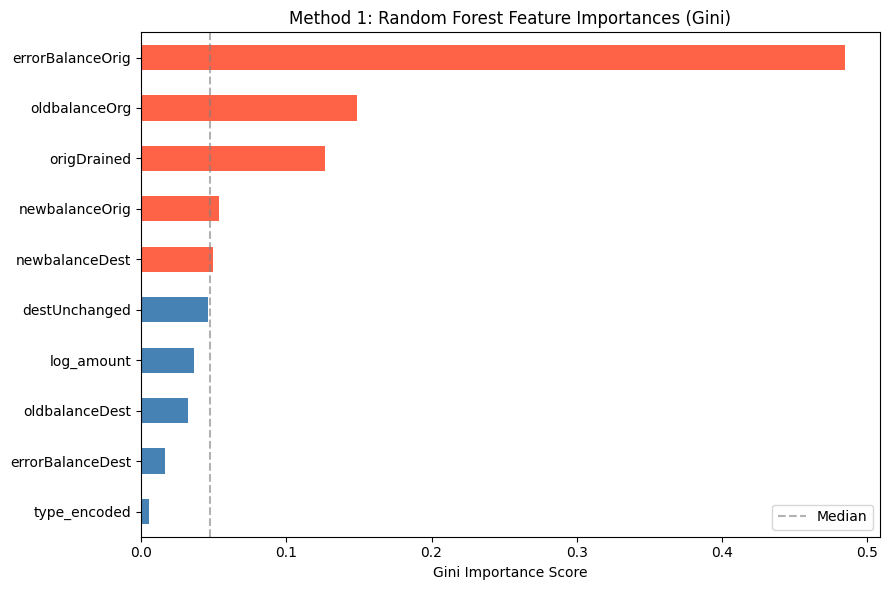

In [12]:
rf_importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['tomato' if imp > rf_importances.median() else 'steelblue' for imp in rf_importances]
rf_importances.plot(kind='barh', color=colors)
plt.axvline(x=rf_importances.median(), color='gray', linestyle='--', alpha=0.6, label='Median')
plt.xlabel('Gini Importance Score')
plt.title('Method 1: Random Forest Feature Importances (Gini)')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
feature_origin = {
    'errorBalanceDest':'Engineered','errorBalanceOrig':'Engineered',
    'destUnchanged':'Engineered','origDrained':'Engineered',
    'log_amount':'Engineered','type_encoded':'Engineered',
    'oldbalanceOrg':'Raw (dataset)','newbalanceOrig':'Raw (dataset)',
    'oldbalanceDest':'Raw (dataset)','newbalanceDest':'Raw (dataset)',
}
imp_df = rf_importances.sort_values(ascending=False).reset_index()
imp_df.columns = ['Feature','Gini Score']
imp_df['Origin'] = imp_df['Feature'].map(feature_origin)
imp_df['Rank'] = range(1, len(imp_df)+1)
print(f"{'Rank':<6}{'Feature':<22}{'Origin':<16}{'Gini Score'}")
print('-'*55)
for _, row in imp_df.iterrows():
    tag = '★' if row['Origin'] == 'Engineered' else ' '
    print(f"  {int(row['Rank']):<4}{row['Feature']:<22}{row['Origin']:<16}{row['Gini Score']:.4f}  {tag}")
print("\n★ = feature created during feature engineering")

Rank  Feature               Origin          Gini Score
-------------------------------------------------------
  1   errorBalanceOrig      Engineered      0.4845  ★
  2   oldbalanceOrg         Raw (dataset)   0.1484   
  3   origDrained           Engineered      0.1269  ★
  4   newbalanceOrig        Raw (dataset)   0.0536   
  5   newbalanceDest        Raw (dataset)   0.0498   
  6   destUnchanged         Engineered      0.0459  ★
  7   log_amount            Engineered      0.0362  ★
  8   oldbalanceDest        Raw (dataset)   0.0326   
  9   errorBalanceDest      Engineered      0.0166  ★
  10  type_encoded          Engineered      0.0056  ★

★ = feature created during feature engineering


### Method 2 — Logistic Regression Coefficients

Plain LR (no PCA) so coefficients map directly back to the original features.

In [ ]:
scaler_q1 = StandardScaler()
X_train_sc = scaler_q1.fit_transform(X_train)
X_test_sc = scaler_q1.transform(X_test)

lr_q1 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
print("Training Logistic Regression (no PCA)...")
lr_q1.fit(X_train_sc, y_train)
print(f"Training complete. Test PR-AUC: {average_precision_score(y_test, lr_q1.predict_proba(X_test_sc)[:,1]):.4f}")

Training Logistic Regression (no PCA)...
Training complete. Test PR-AUC: 0.8745


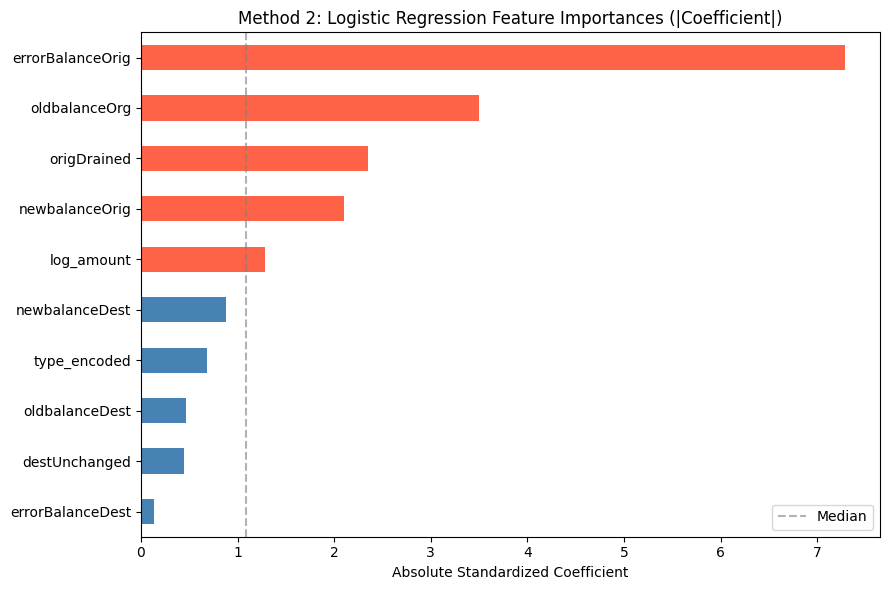

In [15]:
lr_coefs = pd.Series(np.abs(lr_q1.coef_[0]), index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['tomato' if c > lr_coefs.median() else 'steelblue' for c in lr_coefs]
lr_coefs.plot(kind='barh', color=colors)
plt.axvline(x=lr_coefs.median(), color='gray', linestyle='--', alpha=0.6, label='Median')
plt.xlabel('Absolute Standardized Coefficient')
plt.title('Method 2: Logistic Regression Feature Importances (|Coefficient|)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
lr_df = lr_coefs.sort_values(ascending=False).reset_index()
lr_df.columns = ['Feature','|Coefficient|']
lr_df['Origin'] = lr_df['Feature'].map(feature_origin)
lr_df['Rank'] = range(1, len(lr_df)+1)
print(f"{'Rank':<6}{'Feature':<22}{'Origin':<16}{'|Coefficient|'}")
print('-'*60)
for _, row in lr_df.iterrows():
    tag = '★' if row['Origin'] == 'Engineered' else ' '
    print(f"  {int(row['Rank']):<4}{row['Feature']:<22}{row['Origin']:<16}{row['|Coefficient|']:.4f}  {tag}")
print("\n★ = feature created during feature engineering")

Rank  Feature               Origin          |Coefficient|
------------------------------------------------------------
  1   errorBalanceOrig      Engineered      7.2866  ★
  2   oldbalanceOrg         Raw (dataset)   3.5007   
  3   origDrained           Engineered      2.3470  ★
  4   newbalanceOrig        Raw (dataset)   2.1021   
  5   log_amount            Engineered      1.2858  ★
  6   newbalanceDest        Raw (dataset)   0.8852   
  7   type_encoded          Engineered      0.6821  ★
  8   oldbalanceDest        Raw (dataset)   0.4663   
  9   destUnchanged         Engineered      0.4457  ★
  10  errorBalanceDest      Engineered      0.1310  ★

★ = feature created during feature engineering


### Q1 — Side-by-Side Comparison

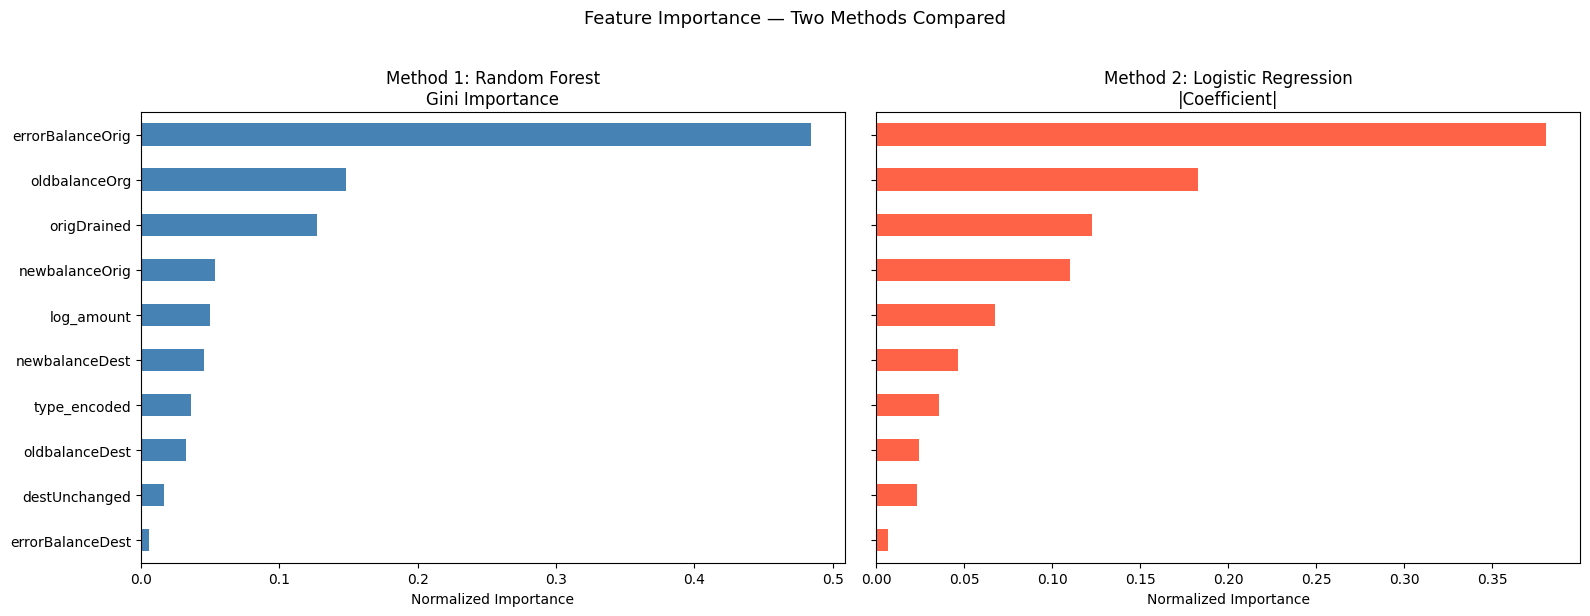


Feature Rank Comparison (lower rank = more important):
                  RF Rank  LR Rank  Rank Diff
Feature                                      
errorBalanceOrig        1        1          0
oldbalanceOrg           2        2          0
origDrained             3        3          0
newbalanceOrig          4        4          0
newbalanceDest          5        6          1
destUnchanged           6        9          3
log_amount              7        5          2
oldbalanceDest          8        8          0
errorBalanceDest        9       10          1
type_encoded           10        7          3


In [17]:
rf_norm = rf_importances / rf_importances.sum()
lr_norm = lr_coefs / lr_coefs.sum()
comparison = pd.DataFrame({'RF Gini (norm)': rf_norm, 'LR |Coef| (norm)': lr_norm}).sort_values('RF Gini (norm)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
comparison['RF Gini (norm)'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Method 1: Random Forest\nGini Importance'); axes[0].set_xlabel('Normalized Importance')
comparison['LR |Coef| (norm)'].sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Method 2: Logistic Regression\n|Coefficient|'); axes[1].set_xlabel('Normalized Importance')
plt.suptitle('Feature Importance — Two Methods Compared', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

rf_r = rf_importances.sort_values(ascending=False).reset_index(); rf_r.columns=['Feature','RF Gini']; rf_r['RF Rank']=range(1,11)
lr_r = lr_coefs.sort_values(ascending=False).reset_index();       lr_r.columns=['Feature','LR |Coef|']; lr_r['LR Rank']=range(1,11)
rt = rf_r.merge(lr_r, on='Feature').set_index('Feature')
rt['Rank Diff'] = abs(rt['RF Rank'] - rt['LR Rank'])
print("\nFeature Rank Comparison (lower rank = more important):")
print(rt[['RF Rank','LR Rank','Rank Diff']].sort_values('RF Rank').to_string())

---
## Research Question 2: Which model best detects fraud?

**Model 1:** Logistic Regression with PCA  |  **Model 2:** Random Forest

Both use the shared feature-engineered dataset and time-based split from preprocessing steps

### Model 1 — Logistic Regression with PCA

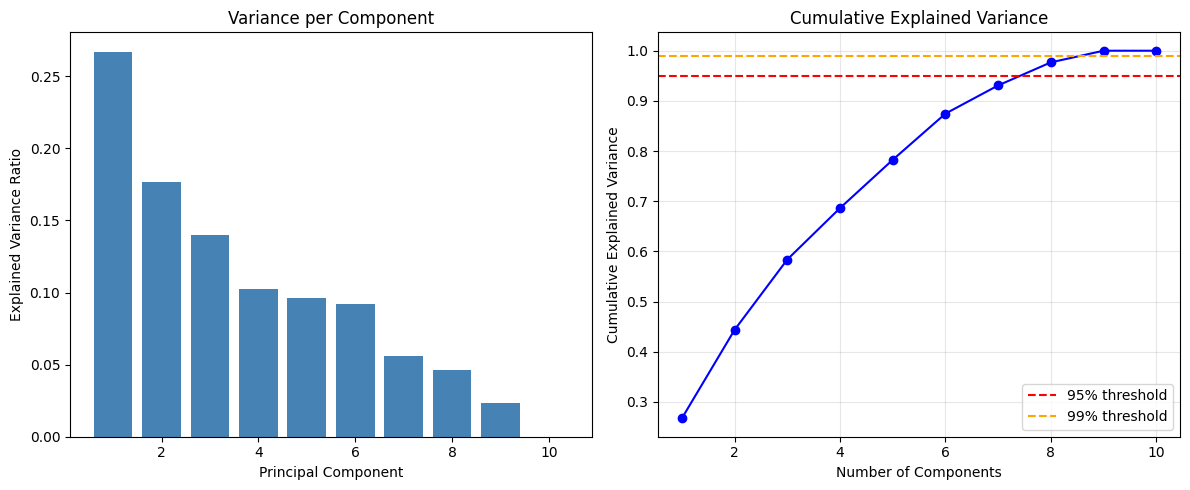

Components for 95% variance: 8


In [18]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train), size=min(100_000, len(X_train)), replace=False)
X_sample   = StandardScaler().fit_transform(X_train[sample_idx])
pca_full   = PCA().fit(X_sample)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1), pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Explained Variance Ratio'); axes[0].set_title('Variance per Component')
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'bo-')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

N_COMPONENTS = int(np.argmax(cumulative >= 0.95)) + 1
print(f"Components for 95% variance: {N_COMPONENTS}")

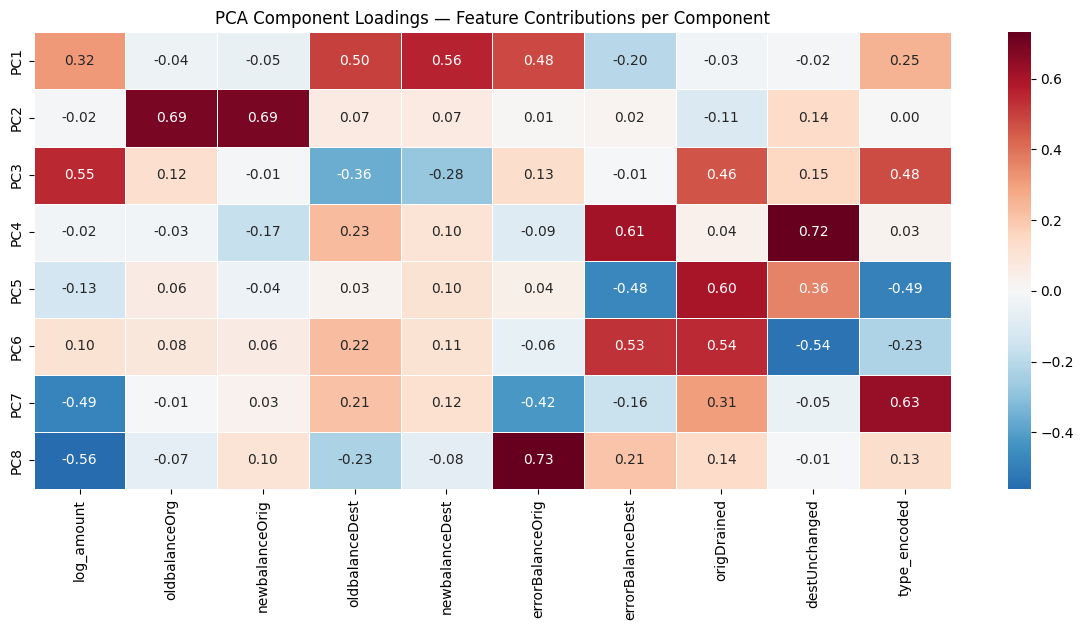

In [19]:
pca_viz = PCA(n_components=N_COMPONENTS)
pca_viz.fit(StandardScaler().fit_transform(X_train[sample_idx]))
loadings = pd.DataFrame(pca_viz.components_, columns=FEATURES, index=[f'PC{i+1}' for i in range(N_COMPONENTS)])
plt.figure(figsize=(12, max(4, N_COMPONENTS*0.8)))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('PCA Component Loadings — Feature Contributions per Component')
plt.tight_layout(); plt.show()

In [ ]:
C_VALUES = [0.01, 0.1, 1.0, 2.0]
val_split       = int(train_df['step'].quantile(0.80))
search_train_df = train_df[train_df['step'] <= val_split]
search_val_df   = train_df[train_df['step'] >  val_split]
X_sv = search_val_df[FEATURES].values; y_sv = search_val_df['isFraud'].values
X_st = search_train_df[FEATURES].values; y_st = search_train_df['isFraud'].values

print(f"Search train: {len(X_st):,} | Fraud: {y_st.sum():,}")
print(f"Search val:   {len(X_sv):,} | Fraud: {y_sv.sum():,}")
print("\nGrid search over C (time-based validation, PR-AUC):\n")
gs_results = []
for C in C_VALUES:
    p = Pipeline([('scaler',StandardScaler()),('pca',PCA(n_components=N_COMPONENTS)),
                  ('clf',LogisticRegression(C=C,class_weight='balanced',max_iter=1000,solver='lbfgs',random_state=42))])
    p.fit(X_st, y_st)
    auc = average_precision_score(y_sv, p.predict_proba(X_sv)[:,1])
    gs_results.append({'C':C,'val_pr_auc':auc})
    print(f"  C={C:6.2f}  ->  PR-AUC: {auc:.4f}")
gs_df  = pd.DataFrame(gs_results)
best_C = gs_df.loc[gs_df['val_pr_auc'].idxmax(), 'C']
print(f"\nBest C: {best_C}")

Search train: 1,780,544 | Fraud: 3,401
Search val:   437,361 | Fraud: 554

Grid search over C (time-based validation, PR-AUC):

  C=  0.01  ->  PR-AUC: 0.6920
  C=  0.10  ->  PR-AUC: 0.7060
  C=  1.00  ->  PR-AUC: 0.7077
  C=  2.00  ->  PR-AUC: 0.7078

Best C: 2.0
Note: validation PR-AUC is lower than test PR-AUC — different fraud rates, scores are relative comparisons only.


In [21]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=N_COMPONENTS)),
    ('clf',    LogisticRegression(C=best_C, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)),
])
print(f"Training LR pipeline with best_C={best_C}...")
pipeline.fit(X_train, y_train)
y_pred_lr  = pipeline.predict(X_test)
y_proba_lr = pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate','Fraud']))
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Training LR pipeline with best_C=2.0...
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98    548246
       Fraud       0.15      1.00      0.26      4258

    accuracy                           0.96    552504
   macro avg       0.57      0.98      0.62    552504
weighted avg       0.99      0.96      0.97    552504

PR-AUC:  0.9240
ROC-AUC: 0.9962


In [ ]:
y_pred_lr_tr  = pipeline.predict(X_train)
y_proba_lr_tr = pipeline.predict_proba(X_train)[:, 1]
pr_tr  = average_precision_score(y_train, y_proba_lr_tr)
pr_te  = average_precision_score(y_test,  y_proba_lr)
roc_tr = roc_auc_score(y_train, y_proba_lr_tr)
roc_te = roc_auc_score(y_test,  y_proba_lr)
print(f"{'Metric':<18} {'Train':>10} {'Test':>10} {'Diff':>10}")
print('─'*50)
print(f"{'PR-AUC':<18} {pr_tr:>10.4f} {pr_te:>10.4f} {pr_te-pr_tr:>+10.4f}")
print(f"{'ROC-AUC':<18} {roc_tr:>10.4f} {roc_te:>10.4f} {roc_te-roc_tr:>+10.4f}")
print(f"{'Recall':<18} {recall_score(y_train,y_pred_lr_tr):>10.4f} {recall_score(y_test,y_pred_lr):>10.4f} {recall_score(y_test,y_pred_lr)-recall_score(y_train,y_pred_lr_tr):>+10.4f}")
print(f"{'Precision':<18} {precision_score(y_train,y_pred_lr_tr):>10.4f} {precision_score(y_test,y_pred_lr):>10.4f} {precision_score(y_test,y_pred_lr)-precision_score(y_train,y_pred_lr_tr):>+10.4f}")
roc_gap = roc_tr - roc_te
print(f"\nNote: PR-AUC is higher on test due to higher fraud rate (0.77% vs 0.18%) — not overfitting.")
print(f"ROC-AUC gap (train - test): {roc_gap:+.4f} — {'generalizing well' if abs(roc_gap)<0.05 else 'possible overfitting'}")

Metric                  Train       Test       Diff
──────────────────────────────────────────────────
PR-AUC                 0.7159     0.9240    +0.2081
ROC-AUC                0.9931     0.9962    +0.0031
Recall                 0.9904     0.9967    +0.0063
Precision              0.0394     0.1474    +0.1079

Note: PR-AUC is higher on test due to higher fraud rate (0.77% vs 0.18%) — not overfitting.
ROC-AUC gap (train - test): -0.0031 — generalizing well


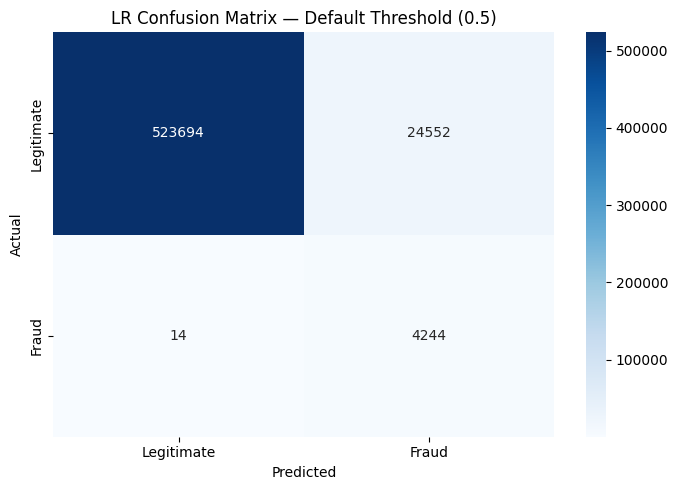

Recall (TPR): 0.9967  |  Precision: 0.1474
TNR:          0.9552  |  FNR:       0.0033


In [23]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
plt.title('LR Confusion Matrix — Default Threshold (0.5)')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()
tn,fp,fn,tp = cm_lr.ravel()
print(f"Recall (TPR): {tp/(tp+fn):.4f}  |  Precision: {tp/(tp+fp):.4f}")
print(f"TNR:          {tn/(tn+fp):.4f}  |  FNR:       {fn/(fn+tp):.4f}")

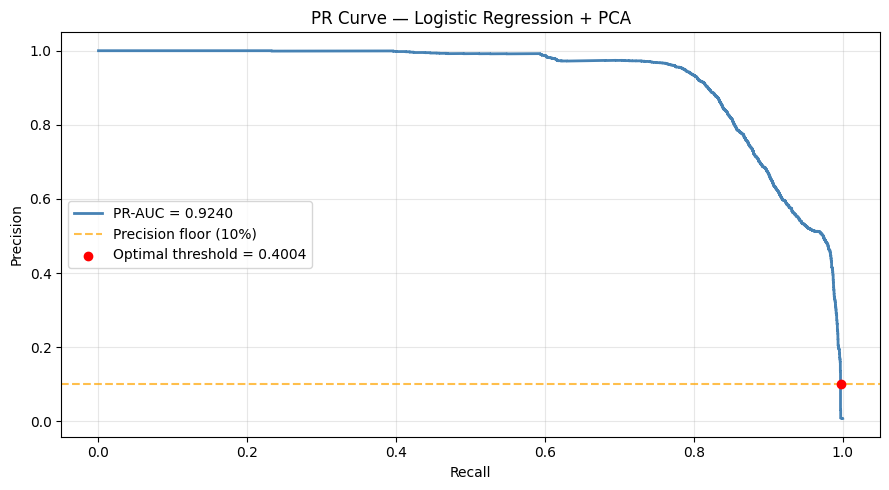

Optimal threshold: 0.4004
Recall: 0.9969  |  Precision: 0.1000


In [24]:
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_proba_lr)
valid_lr     = precision_lr[:-1] >= PRECISION_FLOOR
best_idx_lr  = np.argmax(recall_lr[:-1] * valid_lr)
best_thresh_lr = thresholds_lr[best_idx_lr]

plt.figure(figsize=(9, 5))
plt.plot(recall_lr, precision_lr, color='steelblue', lw=2, label=f'PR-AUC = {average_precision_score(y_test,y_proba_lr):.4f}')
plt.axhline(y=PRECISION_FLOOR, color='orange', linestyle='--', alpha=0.7, label='Precision floor (10%)')
plt.scatter(recall_lr[best_idx_lr], precision_lr[best_idx_lr], color='red', zorder=5,
            label=f'Optimal threshold = {best_thresh_lr:.4f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('PR Curve — Logistic Regression + PCA')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Optimal threshold: {best_thresh_lr:.4f}")
print(f"Recall: {recall_lr[best_idx_lr]:.4f}  |  Precision: {precision_lr[best_idx_lr]:.4f}")

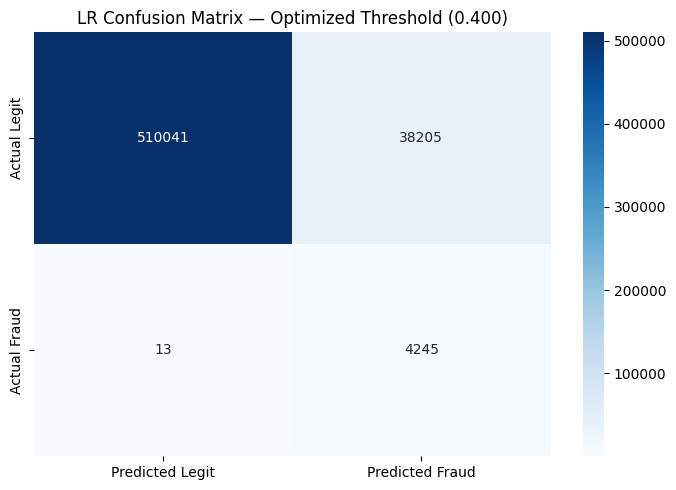

True Positives  (fraud caught):  4,245
False Negatives (fraud missed):  13
False Positives (false alarms):  38,205
True Negatives  (legit cleared): 510,041

Recall (TPR): 0.9969  |  Precision: 0.1000
TNR:          0.9303  |  FNR:       0.0031


In [25]:
y_pred_opt_lr = (y_proba_lr >= best_thresh_lr).astype(int)
cm_opt_lr = confusion_matrix(y_test, y_pred_opt_lr)
tn,fp,fn,tp = cm_opt_lr.ravel()
plt.figure(figsize=(7, 5))
sns.heatmap(cm_opt_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit','Predicted Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
plt.title(f'LR Confusion Matrix — Optimized Threshold ({best_thresh_lr:.3f})')
plt.tight_layout(); plt.show()
print(f"True Positives  (fraud caught):  {tp:,}")
print(f"False Negatives (fraud missed):  {fn:,}")
print(f"False Positives (false alarms):  {fp:,}")
print(f"True Negatives  (legit cleared): {tn:,}")
print(f"\nRecall (TPR): {tp/(tp+fn):.4f}  |  Precision: {tp/(tp+fp):.4f}")
print(f"TNR:          {tn/(tn+fp):.4f}  |  FNR:       {fn/(fn+tp):.4f}")

### Model 2 — Random Forest

With grid search for best hyperparameters

In [26]:
# Grid search to justify hyperparameter choice
val_split_rf = int(train_df['step'].quantile(0.80))
str_df = train_df[train_df['step'] <= val_split_rf]; svl_df = train_df[train_df['step'] > val_split_rf]
X_st_rf = str_df[FEATURES].values; y_st_rf = str_df['isFraud'].values
X_sv_rf = svl_df[FEATURES].values; y_sv_rf = svl_df['isFraud'].values
print(f"Search train: {len(X_st_rf):,} | Fraud: {y_st_rf.sum():,}")
print(f"Search val:   {len(X_sv_rf):,} | Fraud: {y_sv_rf.sum():,}")
print("\nGrid search (9 combinations, 50 trees each):\n")
for depth in [None, 10, 20]:
    for leaf in [1, 5, 10]:
        rf_gs = RandomForestClassifier(n_estimators=50, max_depth=depth, min_samples_leaf=leaf,
                                       class_weight='balanced_subsample', n_jobs=-1, random_state=42)
        rf_gs.fit(X_st_rf, y_st_rf)
        pr = average_precision_score(y_sv_rf, rf_gs.predict_proba(X_sv_rf)[:,1])
        dl = 'None*' if depth is None else str(depth)
        print(f"  max_depth={dl:>5}, min_samples_leaf={leaf}  ->  PR-AUC: {pr:.4f}")
print("\nAll combinations score 1.0000 — defaulting to sklearn defaults (max_depth=None, min_samples_leaf=1)")

Search train: 1,780,544 | Fraud: 3,401
Search val:   437,361 | Fraud: 554

Grid search (9 combinations, 50 trees each):

  max_depth=None*, min_samples_leaf=1  ->  PR-AUC: 1.0000
  max_depth=None*, min_samples_leaf=5  ->  PR-AUC: 1.0000
  max_depth=None*, min_samples_leaf=10  ->  PR-AUC: 1.0000
  max_depth=   10, min_samples_leaf=1  ->  PR-AUC: 1.0000
  max_depth=   10, min_samples_leaf=5  ->  PR-AUC: 1.0000
  max_depth=   10, min_samples_leaf=10  ->  PR-AUC: 1.0000
  max_depth=   20, min_samples_leaf=1  ->  PR-AUC: 1.0000
  max_depth=   20, min_samples_leaf=5  ->  PR-AUC: 1.0000
  max_depth=   20, min_samples_leaf=10  ->  PR-AUC: 1.0000

All combinations score 1.0000 — defaulting to sklearn defaults (max_depth=None, min_samples_leaf=1)


In [27]:
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("Classification Report — Random Forest (default threshold):")
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate','Fraud']))
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

Classification Report — Random Forest (default threshold):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    548246
       Fraud       1.00      1.00      1.00      4258

    accuracy                           1.00    552504
   macro avg       1.00      1.00      1.00    552504
weighted avg       1.00      1.00      1.00    552504

PR-AUC:  1.0000
ROC-AUC: 1.0000


In [28]:
y_pred_rf_tr  = rf.predict(X_train)
y_proba_rf_tr = rf.predict_proba(X_train)[:, 1]
pr_rf_tr  = average_precision_score(y_train, y_proba_rf_tr)
pr_rf_te  = average_precision_score(y_test,  y_proba_rf)
roc_rf_tr = roc_auc_score(y_train, y_proba_rf_tr)
roc_rf_te = roc_auc_score(y_test,  y_proba_rf)
print(f"{'Metric':<18} {'Train':>10} {'Test':>10} {'Diff':>10}")
print('─'*50)
print(f"{'PR-AUC':<18} {pr_rf_tr:>10.4f} {pr_rf_te:>10.4f} {pr_rf_te-pr_rf_tr:>+10.4f}")
print(f"{'ROC-AUC':<18} {roc_rf_tr:>10.4f} {roc_rf_te:>10.4f} {roc_rf_te-roc_rf_tr:>+10.4f}")
print(f"{'Recall':<18} {recall_score(y_train,y_pred_rf_tr):>10.4f} {recall_score(y_test,y_pred_rf):>10.4f}")
print(f"{'Precision':<18} {precision_score(y_train,y_pred_rf_tr):>10.4f} {precision_score(y_test,y_pred_rf):>10.4f}")
roc_gap_rf = roc_rf_tr - roc_rf_te
print(f"\nROC-AUC gap (train - test): {roc_gap_rf:+.4f} — {'generalizing well' if abs(roc_gap_rf)<0.05 else 'possible overfitting'}")

Metric                  Train       Test       Diff
──────────────────────────────────────────────────
PR-AUC                 1.0000     1.0000    -0.0000
ROC-AUC                1.0000     1.0000    -0.0000
Recall                 1.0000     0.9995
Precision              1.0000     1.0000

ROC-AUC gap (train - test): +0.0000 — generalizing well


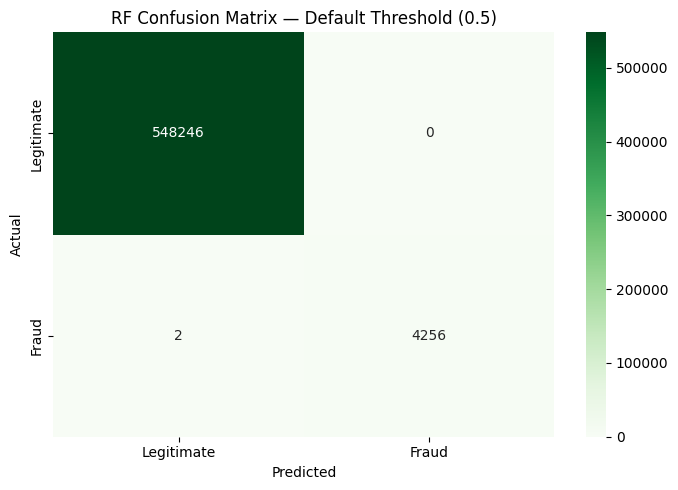

Recall (TPR): 0.9995  |  Precision: 1.0000
TNR:          1.0000  |  FNR:       0.0005


In [29]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
plt.title('RF Confusion Matrix — Default Threshold (0.5)')
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()
tn,fp,fn,tp = cm_rf.ravel()
print(f"Recall (TPR): {tp/(tp+fn):.4f}  |  Precision: {tp/(tp+fp):.4f}")
print(f"TNR:          {tn/(tn+fp):.4f}  |  FNR:       {fn/(fn+tp):.4f}")

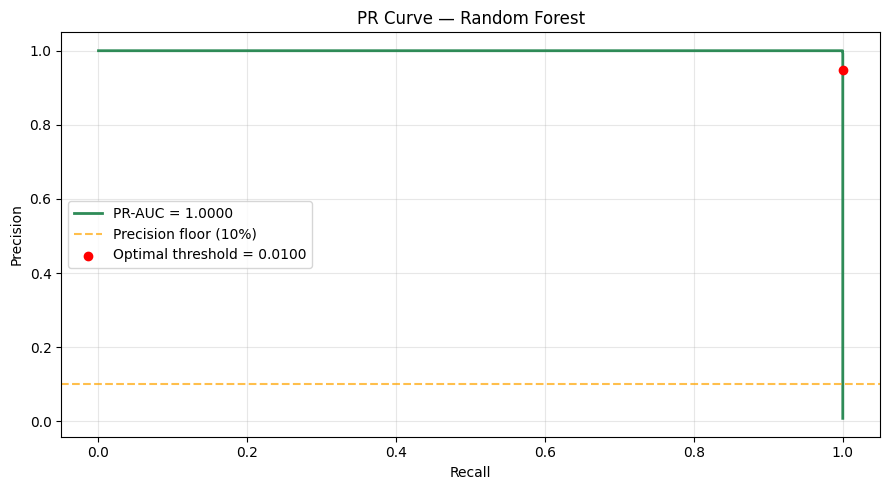

Optimal threshold: 0.0100
Recall: 1.0000  |  Precision: 0.9481


In [30]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)
valid_rf       = precision_rf[:-1] >= PRECISION_FLOOR
best_idx_rf    = np.argmax(recall_rf[:-1] * valid_rf)
best_thresh_rf = thresholds_rf[best_idx_rf]

plt.figure(figsize=(9, 5))
plt.plot(recall_rf, precision_rf, color='seagreen', lw=2, label=f'PR-AUC = {average_precision_score(y_test,y_proba_rf):.4f}')
plt.axhline(y=PRECISION_FLOOR, color='orange', linestyle='--', alpha=0.7, label='Precision floor (10%)')
plt.scatter(recall_rf[best_idx_rf], precision_rf[best_idx_rf], color='red', zorder=5,
            label=f'Optimal threshold = {best_thresh_rf:.4f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('PR Curve — Random Forest')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f"Optimal threshold: {best_thresh_rf:.4f}")
print(f"Recall: {recall_rf[best_idx_rf]:.4f}  |  Precision: {precision_rf[best_idx_rf]:.4f}")

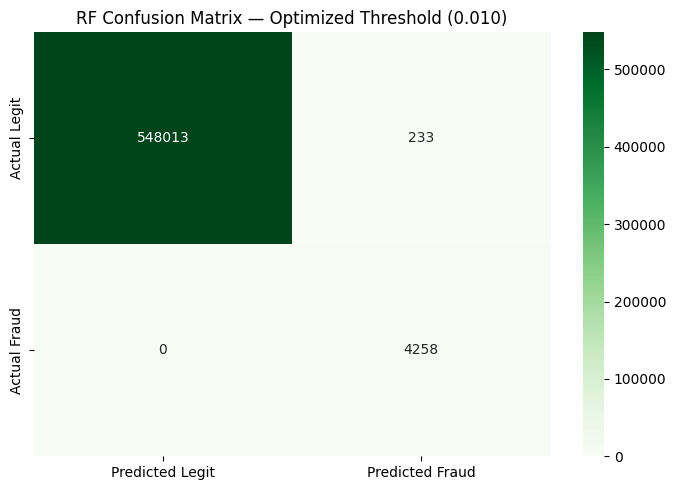

True Positives  (fraud caught):  4,258
False Negatives (fraud missed):  0
False Positives (false alarms):  233
True Negatives  (legit cleared): 548,013

Recall (TPR): 1.0000  |  Precision: 0.9481
TNR:          0.9996  |  FNR:       0.0000


In [31]:
y_pred_opt_rf = (y_proba_rf >= best_thresh_rf).astype(int)
cm_opt_rf = confusion_matrix(y_test, y_pred_opt_rf)
tn,fp,fn,tp = cm_opt_rf.ravel()
plt.figure(figsize=(7, 5))
sns.heatmap(cm_opt_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Legit','Predicted Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
plt.title(f'RF Confusion Matrix — Optimized Threshold ({best_thresh_rf:.3f})')
plt.tight_layout(); plt.show()
print(f"True Positives  (fraud caught):  {tp:,}")
print(f"False Negatives (fraud missed):  {fn:,}")
print(f"False Positives (false alarms):  {fp:,}")
print(f"True Negatives  (legit cleared): {tn:,}")
print(f"\nRecall (TPR): {tp/(tp+fn):.4f}  |  Precision: {tp/(tp+fp):.4f}")
print(f"TNR:          {tn/(tn+fp):.4f}  |  FNR:       {fn/(fn+tp):.4f}")

### Q2 — Model Comparison Summary

In [40]:
lr_cm  = confusion_matrix(y_test, y_pred_opt_lr).ravel()
rf_cm  = confusion_matrix(y_test, y_pred_opt_rf).ravel()
tn_lr, fp_lr, fn_lr, tp_lr = lr_cm
tn_rf, fp_rf, fn_rf, tp_rf = rf_cm

comparison_df = pd.DataFrame({
    'Model':           ['Logistic Regression + PCA', 'Random Forest'],
    'PR-AUC':          [f"{average_precision_score(y_test, y_proba_lr):.3f}",
                        f"~{average_precision_score(y_test, y_proba_rf):.1f}"],
    'Threshold':       [f"{best_thresh_lr:.4f}", f"{best_thresh_rf:.4f}"],
    'Recall':          [f"{tp_lr/(tp_lr+fn_lr):.4f}", f"{tp_rf/(tp_rf+fn_rf):.4f}"],
    'Precision':       [f"{tp_lr/(tp_lr+fp_lr):.4f}", f"{tp_rf/(tp_rf+fp_rf):.4f}"],
    'False Positives': [f"{fp_lr:,}", f"{fp_rf:,}"],
    'Missed Fraud':    [f"{fn_lr:,}", f"{fn_rf:,}"],
})
comparison_df = comparison_df.set_index('Model')
display(comparison_df)


,PR-AUC,Threshold,Recall,Precision,False Positives,Missed Fraud
Model,,,,,,
Logistic Regression + PCA,0.924,0.4004,0.9969,0.1000,"38,205",13
Random Forest,~1.0,0.0100,1.0000,0.9481,233,0


---
## Research Question 3: What is the financial cost of fraud, and how much does our model save?

We use the **Logistic Regression model from Q2** because its imperfect recall creates a meaningful tradeoff

**Cost assumptions:**
- **Missed fraud (FN):** Full transaction amount is lost
- **Caught fraud (TP):** Full transaction amount is saved
- **False alarm (FP):** $25 investigator review cost

**Net Benefit = Money Saved (TP) − Money Lost (FN) − Investigation Cost (FP × $25)**

In [34]:
precision_q3, recall_q3, thresholds_q3 = precision_recall_curve(y_test, y_proba_lr)

valid_q3      = precision_q3[:-1] >= PRECISION_FLOOR
recall_thresh = thresholds_q3[np.argmax(recall_q3[:-1] * valid_q3)]

f1_scores_q3 = 2*(precision_q3[:-1]*recall_q3[:-1]) / (precision_q3[:-1]+recall_q3[:-1]+1e-9)
f1_thresh    = thresholds_q3[np.argmax(f1_scores_q3)]

y_pred_recall = (y_proba_lr >= recall_thresh).astype(int)
y_pred_f1     = (y_proba_lr >= f1_thresh).astype(int)
print(f"Original Recall Priority threshold: {recall_thresh:.4f}")
print(f"F1-Priority threshold:              {f1_thresh:.4f}")

Original Recall Priority threshold: 0.4004
F1-Priority threshold:              0.8659


### Financial Summary — Original Recall Priority vs F1-Priority

In [35]:
def financial_summary(y_true, y_pred, amounts, inv_cost, label):
    tn,fp,fn,tp_c = confusion_matrix(y_true, y_pred).ravel()
    tp_mask = (y_true==1)&(y_pred==1); fn_mask = (y_true==1)&(y_pred==0)
    saved = amounts[tp_mask].sum(); lost = amounts[fn_mask].sum()
    inv   = fp * inv_cost; net = saved - lost - inv
    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Caught (TP): {tp_c:,}  |  Missed (FN): {fn:,}  |  False alarms (FP): {fp:,}")
    print(f"  Recall: {tp_c/(tp_c+fn):.4f}  |  Precision: {tp_c/(tp_c+fp):.4f}")
    print(f"  Money saved  (caught fraud):   ${saved:>15,.2f}")
    print(f"  Money lost   (missed fraud):  -${lost:>15,.2f}")
    print(f"  Investigation cost ($25/FP):  -${inv:>15,.2f}")
    print(f"  {'─'*40}")
    print(f"  Net benefit:                   ${net:>15,.2f}\n")
    return {'label':label,'tp':tp_c,'fn':fn,'fp':fp,'money_saved':saved,'money_lost':lost,'invest_cost':inv,'net_benefit':net}

r_recall = financial_summary(y_test, y_pred_recall, amounts_test, INVESTIGATOR_COST, f'Original Recall Priority (threshold={recall_thresh:.4f})')
r_f1     = financial_summary(y_test, y_pred_f1,     amounts_test, INVESTIGATOR_COST, f'F1-Priority (threshold={f1_thresh:.4f})')

  Original Recall Priority (threshold=0.4004)
  Caught (TP): 4,245  |  Missed (FN): 13  |  False alarms (FP): 38,205
  Recall: 0.9969  |  Precision: 0.1000
  Money saved  (caught fraud):   $6,631,766,030.46
  Money lost   (missed fraud):  -$  70,828,734.90
  Investigation cost ($25/FP):  -$     955,125.00
  ────────────────────────────────────────
  Net benefit:                   $6,559,982,170.56

  F1-Priority (threshold=0.8659)
  Caught (TP): 3,422  |  Missed (FN): 836  |  False alarms (FP): 259
  Recall: 0.8037  |  Precision: 0.9296
  Money saved  (caught fraud):   $6,539,853,165.11
  Money lost   (missed fraud):  -$ 162,741,600.25
  Investigation cost ($25/FP):  -$       6,475.00
  ────────────────────────────────────────
  Net benefit:                   $6,377,105,089.86



### Side-by-Side Comparison Charts

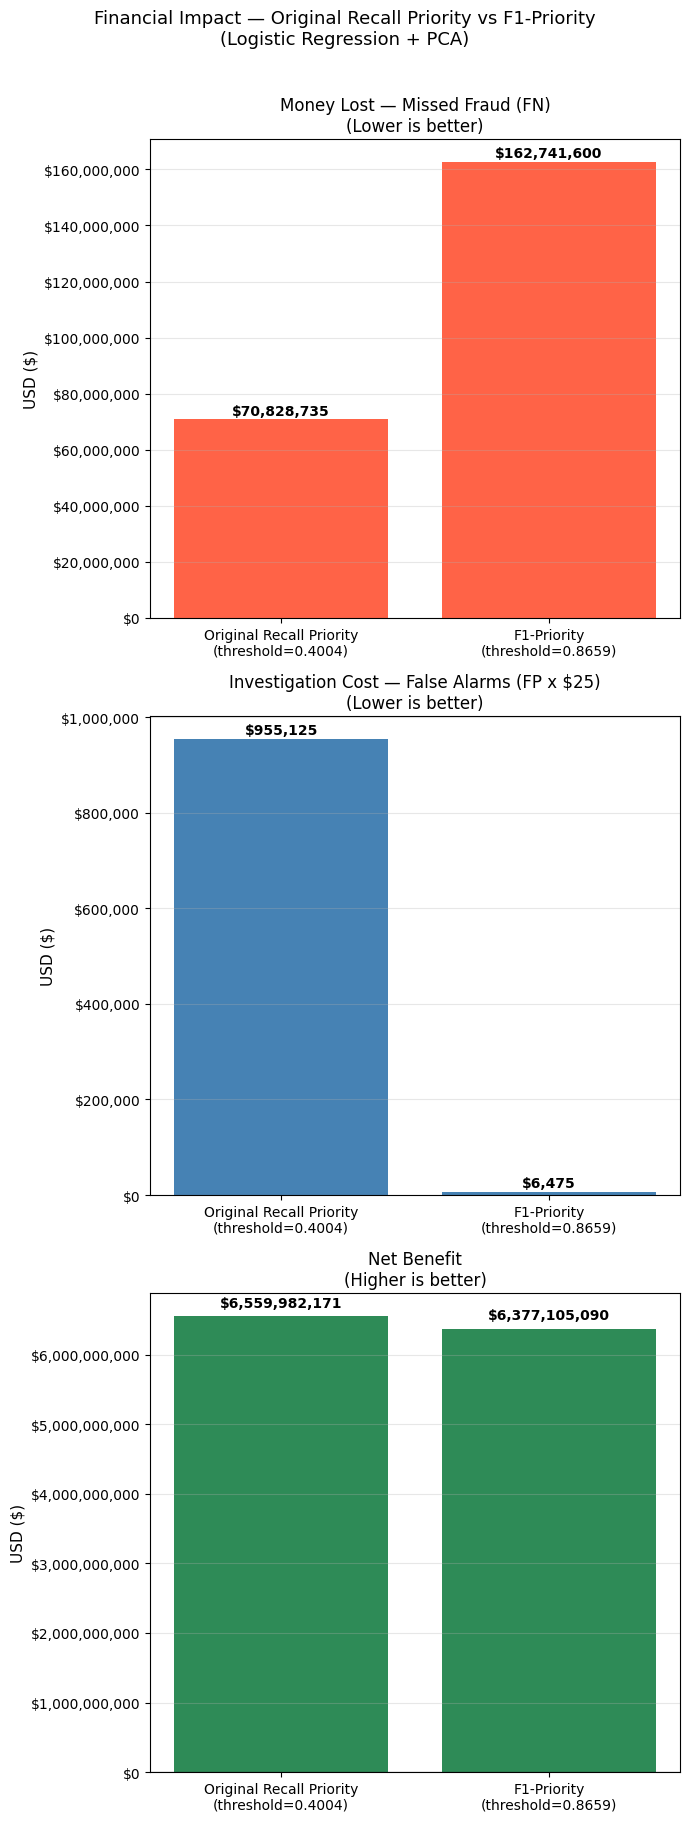

Net benefit difference: $182,877,080.70 in favour of Original Recall Priority


In [36]:
labels   = [f'Original Recall Priority\n(threshold={recall_thresh:.4f})', f'F1-Priority\n(threshold={f1_thresh:.4f})']
lost_v   = [r_recall['money_lost'],  r_f1['money_lost']]
inv_v    = [r_recall['invest_cost'], r_f1['invest_cost']]
net_v    = [r_recall['net_benefit'], r_f1['net_benefit']]

fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(7, 18))

ax1.bar(labels, lost_v, color='tomato', width=0.8)
ax1.set_ylabel('USD ($)', fontsize=11); ax1.set_title('Money Lost — Missed Fraud (FN)\n(Lower is better)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}')); ax1.grid(axis='y', alpha=0.3)
for i,v in enumerate(lost_v): ax1.text(i, v+max(lost_v)*0.01, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

ax2.bar(labels, inv_v, color='steelblue', width=0.8)
ax2.set_ylabel('USD ($)', fontsize=11); ax2.set_title('Investigation Cost — False Alarms (FP x $25)\n(Lower is better)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}')); ax2.grid(axis='y', alpha=0.3)
for i,v in enumerate(inv_v): ax2.text(i, v+max(inv_v)*0.01, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

colors_net = ['seagreen' if v>=0 else 'firebrick' for v in net_v]
ax3.bar(labels, net_v, color=colors_net, width=0.8)
ax3.set_ylabel('USD ($)', fontsize=11); ax3.set_title('Net Benefit\n(Higher is better)', fontsize=12)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:,.0f}'))
ax3.axhline(y=0, color='black', linewidth=0.8); ax3.grid(axis='y', alpha=0.3)
for i,v in enumerate(net_v): ax3.text(i, v+max(abs(n) for n in net_v)*0.02, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Financial Impact — Original Recall Priority vs F1-Priority\n(Logistic Regression + PCA)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
diff = r_recall['net_benefit'] - r_f1['net_benefit']
print(f"Net benefit difference: ${abs(diff):,.2f} in favour of {'Original Recall Priority' if diff>0 else 'F1-Priority'}")

### Threshold Sweep — Full Precision/Recall Tradeoff

Added experiment post presentation to compare thresholds

We test every decision threshold from 0.05 to the F1-optimal in steps of 0.05

The net benefit curve reveals the financially optimal threshold

In [37]:
sweep_results = []
for thresh in np.arange(0.05, f1_thresh+0.001, 0.05):
    yp = (y_proba_lr >= thresh).astype(int)
    tn,fp,fn,tp_c = confusion_matrix(y_test, yp).ravel()
    tp_mask = (y_test==1)&(yp==1); fn_mask = (y_test==1)&(yp==0)
    saved = amounts_test[tp_mask].sum(); lost = amounts_test[fn_mask].sum()
    inv   = fp * INVESTIGATOR_COST; net = saved - lost - inv
    sweep_results.append({
        'threshold': round(thresh,4), 'tp':tp_c, 'fn':fn, 'fp':fp, 'tn':tn,
        'recall':    tp_c/(tp_c+fn) if (tp_c+fn)>0 else 0,
        'precision': tp_c/(tp_c+fp) if (tp_c+fp)>0 else 0,
        'tnr':       tn/(tn+fp)     if (tn+fp)>0   else 0,
        'fnr':       fn/(fn+tp_c)   if (fn+tp_c)>0 else 0,
        'saved_from_caught ($)':   saved,
        'lost_from_missed ($)':    lost,
        'cost_from_false_pos ($)': inv,
        'net_benefit ($)':         net,
    })
sweep_df = pd.DataFrame(sweep_results)
display(sweep_df)

,threshold,tp,fn,fp,tn,recall,precision,tnr,fnr,saved_from_caught ($),lost_from_missed ($),cost_from_false_pos ($),net_benefit ($)
0,0.05,4246,12,135352,412894,0.997182,0.030416,0.753118,0.002818,6.631900e+09,7.069510e+07,3383800,6.557821e+09
1,0.10,4245,13,104544,443702,0.996947,0.039020,0.809312,0.003053,6.631766e+09,7.082873e+07,2613600,6.558324e+09
2,0.15,4245,13,87256,460990,0.996947,0.046393,0.840845,0.003053,6.631766e+09,7.082873e+07,2181400,6.558756e+09
3,0.20,4245,13,74244,474002,0.996947,0.054084,0.864579,0.003053,6.631766e+09,7.082873e+07,1856100,6.559081e+09
4,0.25,4245,13,63464,484782,0.996947,0.062695,0.884242,0.003053,6.631766e+09,7.082873e+07,1586600,6.559351e+09
5,0.30,4245,13,54174,494072,0.996947,0.072665,0.901187,0.003053,6.631766e+09,7.082873e+07,1354350,6.559583e+09
6,0.35,4245,13,45960,502286,0.996947,0.084553,0.916169,0.003053,6.631766e+09,7.082873e+07,1149000,6.559788e+09
7,0.40,4245,13,38253,509993,0.996947,0.099887,0.930227,0.003053,6.631766e+09,7.082873e+07,956325,6.559981e+09
8,0.45,4245,13,31224,517022,0.996947,0.119682,0.943047,0.003053,6.631766e+09,7.082873e+07,780600,6.560157e+09
9,0.50,4244,14,24552,523694,0.996712,0.147382,0.955217,0.003288,6.631640e+09,7.095480e+07,613800,6.560071e+09


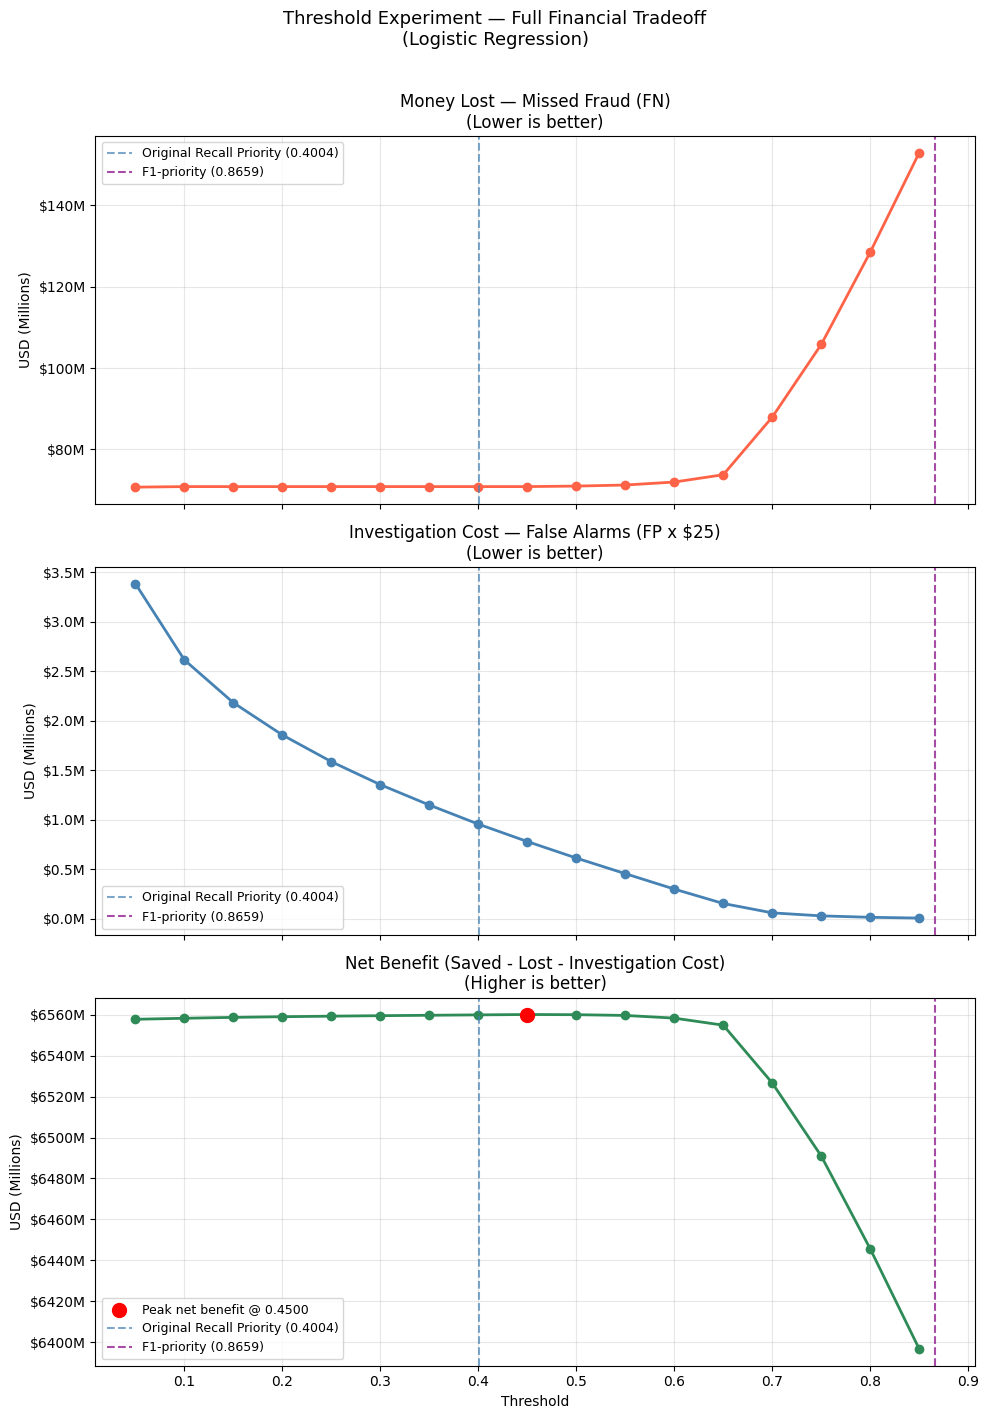

Peak net benefit: $6,560,156,695.56 at threshold=0.4500
  Recall: 0.9969  |  Precision: 0.1197  |  TNR: 0.9430  |  FNR: 0.0031
  Saved from caught fraud:   $6,631,766,030.46
  Lost from missed fraud:   -$  70,828,734.90
  Investigation cost:       -$     780,600.00


In [38]:
fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)
x = sweep_df['threshold']

axes[0].plot(x, sweep_df['lost_from_missed ($)']/1e6, color='tomato', marker='o', linewidth=2)
axes[0].set_ylabel('USD (Millions)'); axes[0].set_title('Money Lost — Missed Fraud (FN)\n(Lower is better)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.0f}M'))
axes[0].grid(alpha=0.3)
axes[0].axvline(x=recall_thresh, color='steelblue', linestyle='--', alpha=0.7, label=f'Original Recall Priority ({recall_thresh:.4f})')
axes[0].axvline(x=f1_thresh,     color='purple',    linestyle='--', alpha=0.7, label=f'F1-priority ({f1_thresh:.4f})')
axes[0].legend(fontsize=9)

axes[1].plot(x, sweep_df['cost_from_false_pos ($)']/1e6, color='steelblue', marker='o', linewidth=2)
axes[1].set_ylabel('USD (Millions)'); axes[1].set_title('Investigation Cost — False Alarms (FP x $25)\n(Lower is better)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.1f}M'))
axes[1].grid(alpha=0.3)
axes[1].axvline(x=recall_thresh, color='steelblue', linestyle='--', alpha=0.7, label=f'Original Recall Priority ({recall_thresh:.4f})')
axes[1].axvline(x=f1_thresh,     color='purple',    linestyle='--', alpha=0.7, label=f'F1-priority ({f1_thresh:.4f})')
axes[1].legend(fontsize=9)

axes[2].plot(x, sweep_df['net_benefit ($)']/1e6, color='seagreen', marker='o', linewidth=2)
axes[2].set_ylabel('USD (Millions)'); axes[2].set_title('Net Benefit (Saved - Lost - Investigation Cost)\n(Higher is better)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v:.0f}M'))
axes[2].set_xlabel('Threshold'); axes[2].grid(alpha=0.3)
best_row = sweep_df.loc[sweep_df['net_benefit ($)'].idxmax()]
axes[2].scatter(best_row['threshold'], best_row['net_benefit ($)']/1e6, color='red', zorder=5, s=100,
                label=f"Peak net benefit @ {best_row['threshold']:.4f}")
axes[2].axvline(x=recall_thresh, color='steelblue', linestyle='--', alpha=0.7, label=f'Original Recall Priority ({recall_thresh:.4f})')
axes[2].axvline(x=f1_thresh,     color='purple',    linestyle='--', alpha=0.7, label=f'F1-priority ({f1_thresh:.4f})')
axes[2].legend(fontsize=9)

plt.suptitle('Threshold Experiment — Full Financial Tradeoff\n(Logistic Regression)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"Peak net benefit: ${best_row['net_benefit ($)']:,.2f} at threshold={best_row['threshold']:.4f}")
print(f"  Recall: {best_row['recall']:.4f}  |  Precision: {best_row['precision']:.4f}  |  TNR: {best_row['tnr']:.4f}  |  FNR: {best_row['fnr']:.4f}")
print(f"  Saved from caught fraud:   ${best_row['saved_from_caught ($)']:>15,.2f}")
print(f"  Lost from missed fraud:   -${best_row['lost_from_missed ($)']:>15,.2f}")
print(f"  Investigation cost:       -${best_row['cost_from_false_pos ($)']:>15,.2f}")